# RNN Model Machine learning notebook for Industrial Analytics
Build by: Florian Schulz<br>
Goal: Build a machine learning model using RNN and visualize it's performance

## Load enviroment variables and create ORM connection
The following cell has to be run to run anything in this project

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
from sqlalchemy import create_engine

load_dotenv()

HOST, PWD, USER, PORT = '127.0.0.1', os.getenv("PWD"), os.getenv("USER"), '3306'

engine = create_engine(
    f"mysql+mysqlconnector://{USER}:{PWD}@{HOST}:{PORT}/mexico_toy_store_wh_db"
)

### Load Global demand data
The following cell loads all the demand of all shops into a pandas dataframe<br>
You can see that the data we are using is very uncomplicated, just the day and the total units sold across all shops, perfect for a first simple model

In [2]:
with open(r'../sql/rnn-query/units_sold_per_day_global.sql', 'r', encoding='utf-8') as f:
    query = f.read()

df = pd.read_sql(query, engine)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(df.head())
print('-----------------------------------------------')
print(df.info())

        date  total_units_sold
0 2022-01-01            2970.0
1 2022-01-02            2812.0
2 2022-01-03            1500.0
3 2022-01-04            1920.0
4 2022-01-05            2740.0
-----------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              638 non-null    datetime64[ns]
 1   total_units_sold  638 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 10.1 KB
None


### Set date as Index
Every day can be only once in the dataset, so we can use it as Index for our RNN later.<br>
We also check if there is any missing days, which we already know from our earlier presentation that there isn't.

In [3]:
df = df.set_index("date")

full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="D"
)

df = df.reindex(full_index)
df.index.name = "date"

# missing days = zero demand (retail assumption)
df["total_units_sold"] = df["total_units_sold"].fillna(0)

print("Missing dates after fill:", df.isna().sum())


Missing dates after fill: total_units_sold    0
dtype: int64


### Feature engineering
An RNN is a very simple machine learning model, it basically takes every factor you give it and tries to see an indication for it's next prediciton step.<br>
Features we add are:
<ul>
    <li>Weekdays (Maybe weekends have higher sales than weekdays)</li>
    <li>Count of day in the year (Christmas sales maybe around day 344 - 359, this is relevant for our model)</li>
    <li>Month (Some months are just higher in demand than others)</li>
    <li>Lag</li>
    <li>Rolling mean</li>
</ul>
Rolling mean and lag are great indicators for obvious patterns, which the RNN doesn't have to figure out by itself, you see how they behave on the graph below.
<br><br>
Important to notice is that RNN's can't deal with circularity, for an RNN it doesn't make sense why the count of days reset to 1 after 365. It understands consitent curves like Sin and Cos.

In [4]:
import numpy as np

# Create the first three features
df["day_of_week"] = df.index.dayofweek        # 0–6
df["day_of_year"] = df.index.dayofyear
df["month"] = df.index.month

# Encode them cyclical
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

# lags, per day, week and fortneight
df["lag_1"] = df["total_units_sold"].shift(1)
df["lag_7"] = df["total_units_sold"].shift(7)
df["lag_14"] = df["total_units_sold"].shift(14)

# rolling mean weekly and monthly
df["roll_mean_7"] = df["total_units_sold"].rolling(7).mean()
df["roll_mean_30"] = df["total_units_sold"].rolling(30).mean()

# Drop all rows of first month because they have na values due to rolling mean and lag
df = df.dropna()

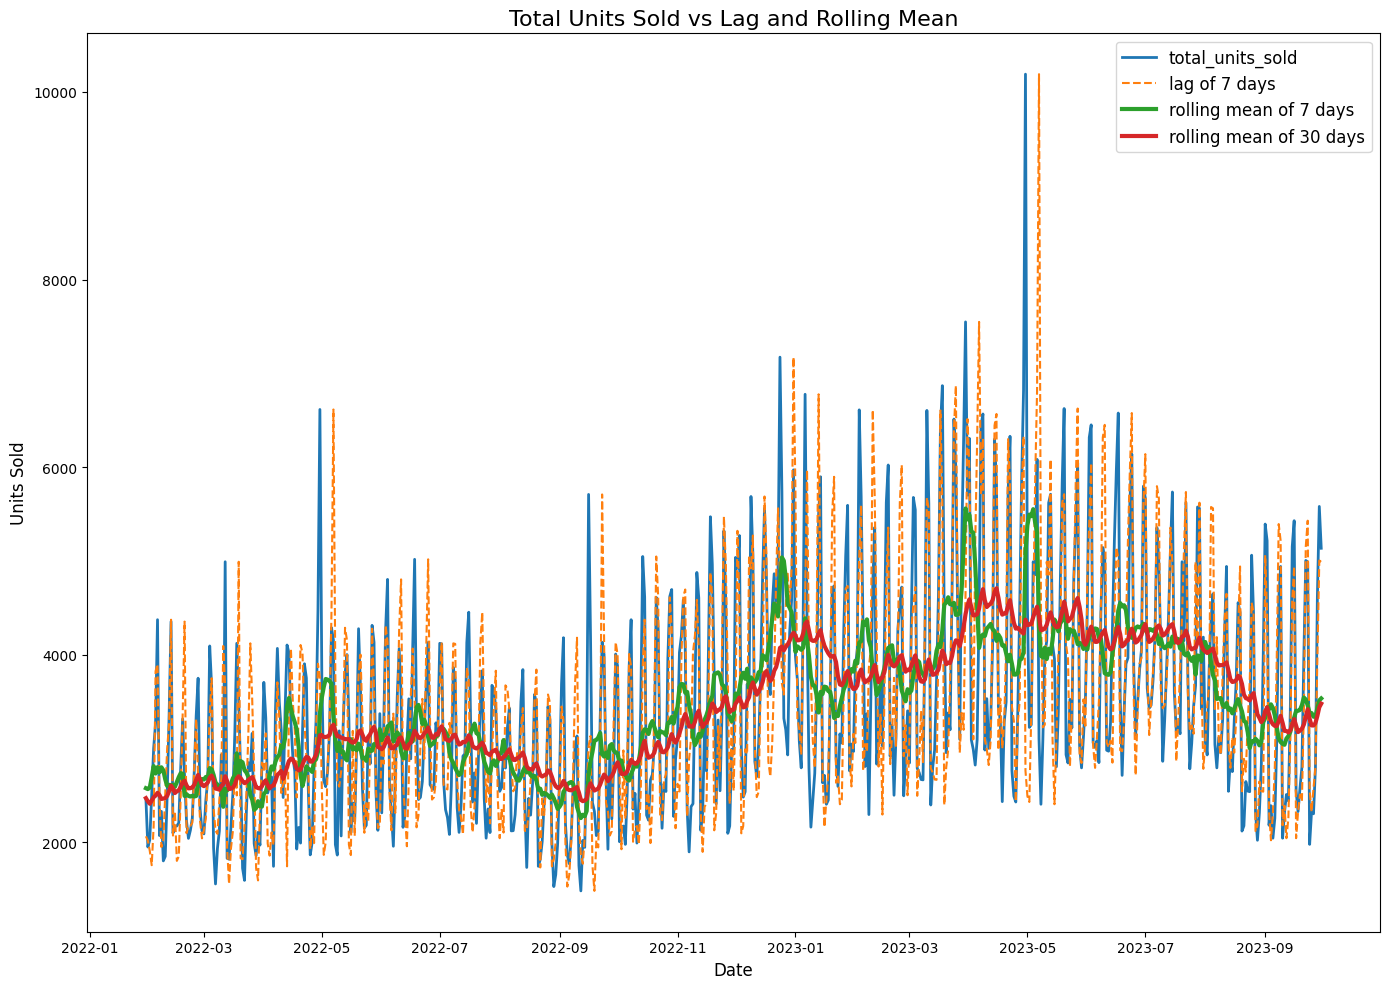

In [5]:
# Visualisation of Lag rolling mean and actual sales
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

plt.plot(
    df.index,
    df["total_units_sold"],
    label="total_units_sold",
    linewidth=2
)

plt.plot(
    df.index,
    df["lag_7"],
    label="lag of 7 days",
    linestyle="--"
)

plt.plot(
    df.index,
    df["roll_mean_7"],
    label="rolling mean of 7 days",
    linewidth=3
)

plt.plot(
    df.index,
    df["roll_mean_30"],
    label="rolling mean of 30 days",
    linewidth=3
)


plt.title("Total Units Sold vs Lag and Rolling Mean", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Units Sold", fontsize=12)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

### Scaling
Neural networks are using gradients, if we don't scale, large values like total_units_sold (Values like 2970.00) dominate and small values like dow_sin (it's from min -1 to max +1) become irrelevant.<br>
When everyhing is upscaled the target (y) also needs to be upscaled, otherwise we lose a huge amount of values.

In [6]:
from sklearn.preprocessing import StandardScaler

features = [
    "lag_1", "lag_7", "lag_14",
    "roll_mean_7", "roll_mean_30",
    "dow_sin", "dow_cos",
    "doy_sin", "doy_cos"
]

target = "total_units_sold"

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(df[features])
y = scaler_y.fit_transform(df[[target]])

### Sequencing
An RNN is designed to process ordered data. A sequence is a fixed length of sequential values. SEQ_Len = 30 is basically saying look at the last 30 days and predict tomorrow.

In [7]:
SEQ_LEN = 30

def build_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = build_sequences(X, y, SEQ_LEN)

print(X_seq.shape)  # (samples, timesteps, features)
print(y_seq.shape)  # Amount of samples should be equal

(579, 30, 9)
(579, 1)


### Splitting the dataset
The split itself isn't that important, it's rather important that the split is time ordered, so that the validation data can be the future data. Because this dataset is a bit smaller I do 80/20, so that there is bit more training than normally with 70/30.<br>
Rule of thumb is round about the time I want to predict, I should have in my validation set.<br>
1 year forecast --> validaton set of round about 1 year

In [14]:
split = int(0.8 * len(X_seq))

X_train, X_val = X_seq[:split], X_seq[split:]
y_train, y_val = y_seq[:split], y_seq[split:]

print(f'Amount of days the model will be trained on: {len(X_train)}, Amount of days in the validation set: {len(X_val)}, that is round about {round(len(X_val)/30, 2)} months of forecasting.')

Amount of days the model will be trained on: 463, Amount of days in the validation set: 116, that is round about 3.87 months of forecasting.


### Set up PyTorch dataset
Set up class to serve values for the training later on.

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### GRU Model
Time series  models aren't that good in keeping long term information. The GRU model is a grat addition to a time series model, because it basicaly decides at each timestep if information should be forgotten or remembered. We can also try using LSTM later on, which is better for very longer sequences.

In [10]:
import torch.nn as nn

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

### Training loop

In [11]:
train_loader = DataLoader(
    TimeSeriesDataset(X_train, y_train),
    batch_size=32,
    shuffle=False
)

val_loader = DataLoader(
    TimeSeriesDataset(X_val, y_val),
    batch_size=32,
    shuffle=False
)

model = GRUModel(input_size=X_train.shape[2])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

### Executing training

In [12]:
for epoch in range(20):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            val_loss += criterion(preds, yb).item()

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train {train_loss/len(train_loader):.4f} | "
        f"Val {val_loss/len(val_loader):.4f}"
    )

Epoch 01 | Train 0.8408 | Val 0.6615
Epoch 02 | Train 0.6532 | Val 0.5556
Epoch 03 | Train 0.5518 | Val 0.4585
Epoch 04 | Train 0.4737 | Val 0.3719
Epoch 05 | Train 0.4142 | Val 0.3095
Epoch 06 | Train 0.3781 | Val 0.2722
Epoch 07 | Train 0.3586 | Val 0.2509
Epoch 08 | Train 0.3455 | Val 0.2362
Epoch 09 | Train 0.3335 | Val 0.2241
Epoch 10 | Train 0.3219 | Val 0.2131
Epoch 11 | Train 0.3113 | Val 0.2028
Epoch 12 | Train 0.3018 | Val 0.1934
Epoch 13 | Train 0.2934 | Val 0.1852
Epoch 14 | Train 0.2862 | Val 0.1782
Epoch 15 | Train 0.2801 | Val 0.1725
Epoch 16 | Train 0.2751 | Val 0.1679
Epoch 17 | Train 0.2710 | Val 0.1645
Epoch 18 | Train 0.2677 | Val 0.1621
Epoch 19 | Train 0.2649 | Val 0.1603
Epoch 20 | Train 0.2626 | Val 0.1591


### Evaluation
The model had a clean decreasing validation and training loss, based on the graph below the model followed the actual data extremly well.

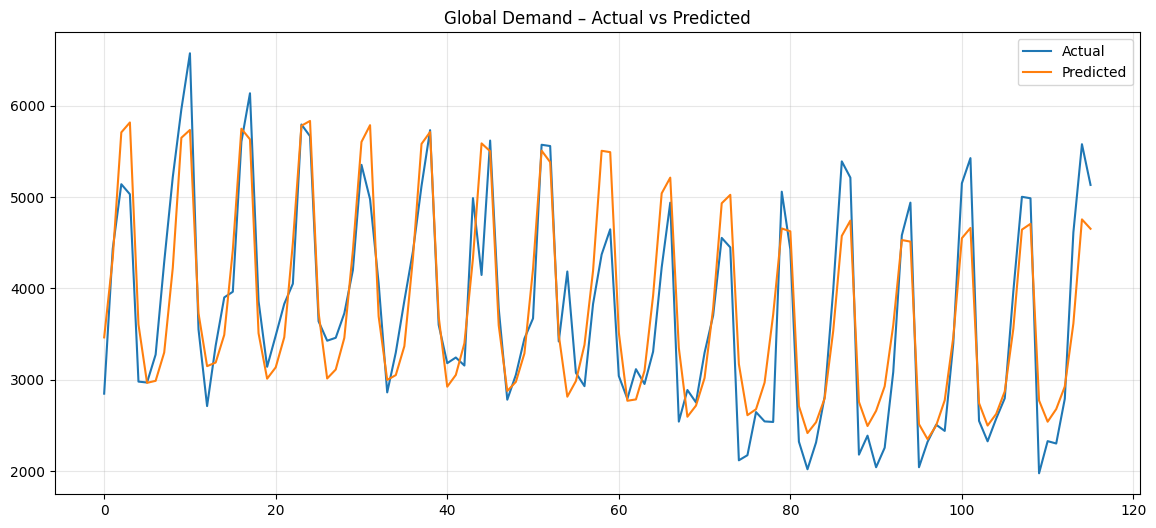

In [13]:
model.eval()

with torch.no_grad():
    preds = model(torch.tensor(X_val, dtype=torch.float32)).numpy()

# inverse scaling
y_val_inv = scaler_y.inverse_transform(y_val)
preds_inv = scaler_y.inverse_transform(preds)

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(y_val_inv[:200], label="Actual")
plt.plot(preds_inv[:200], label="Predicted")
plt.title("Global Demand – Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Would this model have worked in the past?

In [15]:
# Inverse the scaling which we have done earlier
def inverse_transform_y(y_scaled, scaler):
    return scaler.inverse_transform(y_scaled.reshape(-1, 1)).ravel()

In [20]:
import torch
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

def walk_forward_backtest(
    model_class,
    X_seq,
    y_seq,
    scaler_y,
    train_size,
    retrain_every=1,
    epochs=10,
    lr=1e-3
):
    preds = []
    actuals = []

    for t in range(train_size, len(X_seq)):
        X_train = X_seq[:t]
        y_train = y_seq[:t]
        X_test = X_seq[t:t+1]
        y_test = y_seq[t:t+1]

        # Reinitialize model periodically
        if (t - train_size) % retrain_every == 0:
            model = model_class(input_size=X_seq.shape[2])
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            criterion = torch.nn.MSELoss()

            # Train
            model.train()
            for _ in range(epochs):
                optimizer.zero_grad()
                preds_train = model(torch.tensor(X_train, dtype=torch.float32))
                loss = criterion(preds_train, torch.tensor(y_train, dtype=torch.float32))
                loss.backward()
                optimizer.step()

        # Predict next step
        model.eval()
        with torch.no_grad():
            pred = model(torch.tensor(X_test, dtype=torch.float32)).numpy()

        preds.append(pred[0, 0])
        actuals.append(y_test[0, 0])

    # Inverse scale
    preds = inverse_transform_y(np.array(preds), scaler_y)
    actuals = inverse_transform_y(np.array(actuals), scaler_y)

    return preds, actuals

In [21]:
INITIAL_TRAIN_SIZE = int(0.6 * len(X_seq))

preds, actuals = walk_forward_backtest(
    model_class=GRUModel,
    X_seq=X_seq,
    y_seq=y_seq,
    scaler_y=scaler_y,
    train_size=INITIAL_TRAIN_SIZE,
    retrain_every=7,   # retrain weekly
    epochs=5
)

In [22]:
rmse = root_mean_squared_error(actuals, preds)
mae = mean_absolute_error(actuals, preds)

print(f"Backtest RMSE: {rmse:.2f}")
print(f"Backtest MAE : {mae:.2f}")

Backtest RMSE: 1385.83
Backtest MAE : 1078.40


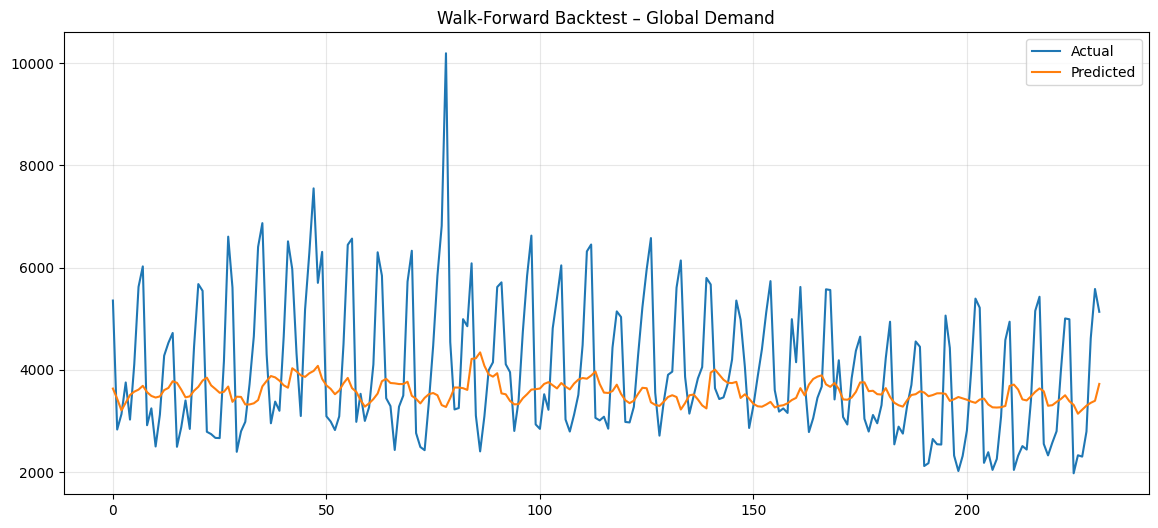

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(actuals, label="Actual")
plt.plot(preds, label="Predicted")
plt.title("Walk-Forward Backtest – Global Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.show()